## Evidential Regression 파이썬 예시

Epoch 50/500, Loss: 2.1061
Epoch 100/500, Loss: 1.7812
Epoch 150/500, Loss: 1.4430
Epoch 200/500, Loss: 1.0606
Epoch 250/500, Loss: 0.9925
Epoch 300/500, Loss: 0.9689
Epoch 350/500, Loss: 0.9532
Epoch 400/500, Loss: 0.9410
Epoch 450/500, Loss: 0.9313
Epoch 500/500, Loss: 0.9219


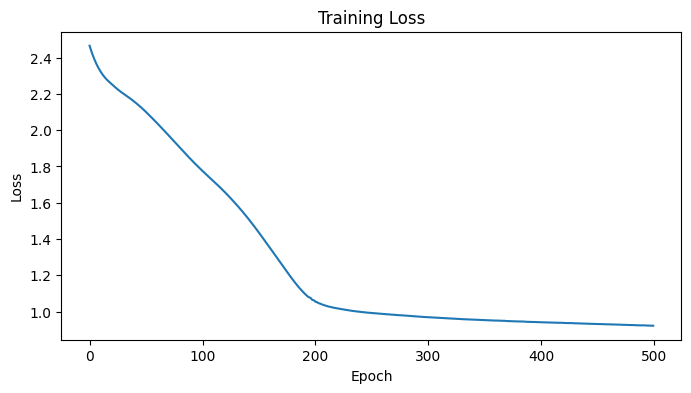

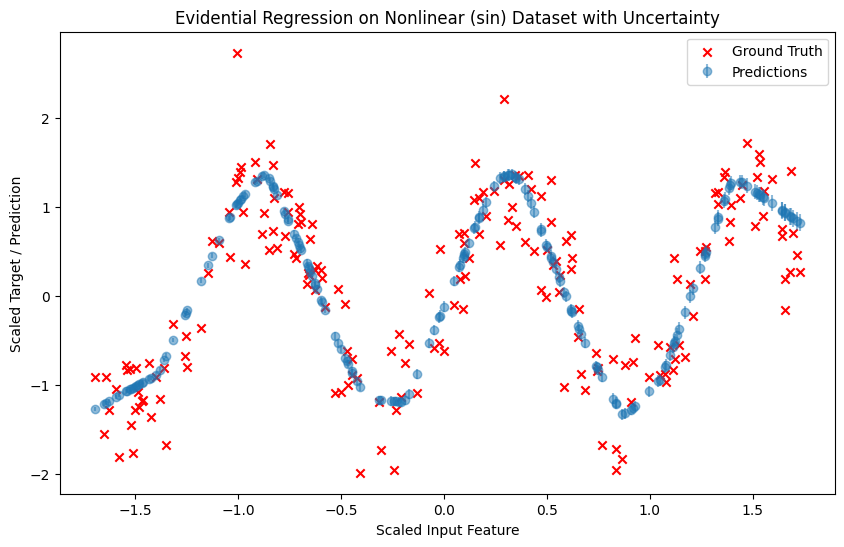

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. 데이터 생성 및 전처리
np.random.seed(42)
torch.manual_seed(42)

# 비선형 데이터셋 생성: y = sin(x) + noise
# - x는 -3부터 3까지 균등하게 분포한 1000개의 데이터 포인트
# - y는 sin(x)에 작은 정규분포 노이즈를 추가
X = np.linspace(-3, 3, 1000).reshape(-1, 1).astype(np.float32)
y = 2*np.sin(3*X) + np.random.normal(scale=0.7, size=X.shape).astype(np.float32)

# 데이터 스케일링
scaler_X = StandardScaler().fit(X)
scaler_y = StandardScaler().fit(y)
X = scaler_X.transform(X)
y = scaler_y.transform(y)

# 학습/테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 텐서 변환
X_train = torch.tensor(X_train)
y_train = torch.tensor(y_train)
X_test = torch.tensor(X_test)
y_test = torch.tensor(y_test)

# 2. Evidential Regression 모델 정의
class EvidentialRegression(nn.Module):
    def __init__(self, in_features, hidden_features):
        super(EvidentialRegression, self).__init__()
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.fc2 = nn.Linear(hidden_features, hidden_features)
        # 최종 출력: μ, v, α, β (각각 하나의 스칼라)
        self.out = nn.Linear(hidden_features, 4)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        output = self.out(x)
        # 첫 번째 출력: 예측된 평균 μ (선형 출력)
        mu = output[:, 0:1]
        # 나머지 출력들은 양의 값을 갖도록 softplus 적용
        v = F.softplus(output[:, 1:2]) + 1e-6      # 평균의 증거 (양수)
        alpha = F.softplus(output[:, 2:3]) + 1.0     # α > 1을 보장하기 위해 +1
        beta = F.softplus(output[:, 3:4]) + 1e-6     # scale 파라미터 (양수)
        return mu, v, alpha, beta

# 3. Evidential Regression Loss 함수 정의
def evidential_regression_loss(y, mu, v, alpha, beta, coeff=10.0):
    """
    Negative Log Marginal Likelihood (NLL)와 정규화 항의 합.
    
    NLL 항:
      0.5*log(pi/v) - alpha*log(2*beta*(1+v)) +
      (alpha+0.5)*log((y-mu)^2 * v + 2*beta*(1+v)) +
      lgamma(alpha) - lgamma(alpha+0.5)
    
    정규화 항은 모델이 지나치게 증거를 축적하지 않도록 예측 오차에 비례하여 패널티를 부여.
    """
    two_beta_v = 2 * beta * (1 + v)
    error = (y - mu) ** 2
    nll = 0.5 * torch.log(np.pi / v) \
          - alpha * torch.log(two_beta_v) \
          + (alpha + 0.5) * torch.log(error * v + two_beta_v) \
          + torch.lgamma(alpha) - torch.lgamma(alpha + 0.5)
    
    reg = coeff * torch.abs(y - mu)
    
    return torch.mean(nll + reg)

# 4. 모델, 옵티마이저, 및 학습 설정
model = EvidentialRegression(in_features=1, hidden_features=64)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 500

# 5. 학습 루프
loss_history = []
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    mu, v, alpha, beta = model(X_train)
    loss = evidential_regression_loss(y_train, mu, v, alpha, beta, coeff=1.0)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")

# 학습 손실 시각화
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

# 6. 테스트 데이터에 대한 예측 및 불확실성 평가
model.eval()
with torch.no_grad():
    mu_test, v_test, alpha_test, beta_test = model(X_test)

# 예측값은 μ이며 불확실성은 예측 분포의 분산 추정으로 beta/(alpha-1)를 사용 (α > 1 가정)
uncertainty = (beta_test / (alpha_test - 1)).squeeze().cpu().numpy()
mu_pred = mu_test.squeeze().cpu().numpy()
y_true = y_test.squeeze().cpu().numpy()

# 7. 예측값과 불확실성 시각화
plt.figure(figsize=(10, 6))
# 에러 바로 예측의 불확실성(에러 바의 길이로 표현)
plt.errorbar(X_test.squeeze().cpu().numpy(), mu_pred, yerr=uncertainty, fmt='o', alpha=0.5, label="Predictions")
# 실제 값은 붉은색 x 표시로 나타냄
plt.scatter(X_test.squeeze().cpu().numpy(), y_true, color='red', marker='x', label="Ground Truth")
plt.xlabel("Scaled Input Feature")
plt.ylabel("Scaled Target / Prediction")
plt.legend()
plt.title("Evidential Regression on Nonlinear (sin) Dataset with Uncertainty")
plt.show()


Epoch 500/500, Loss: -0.4021


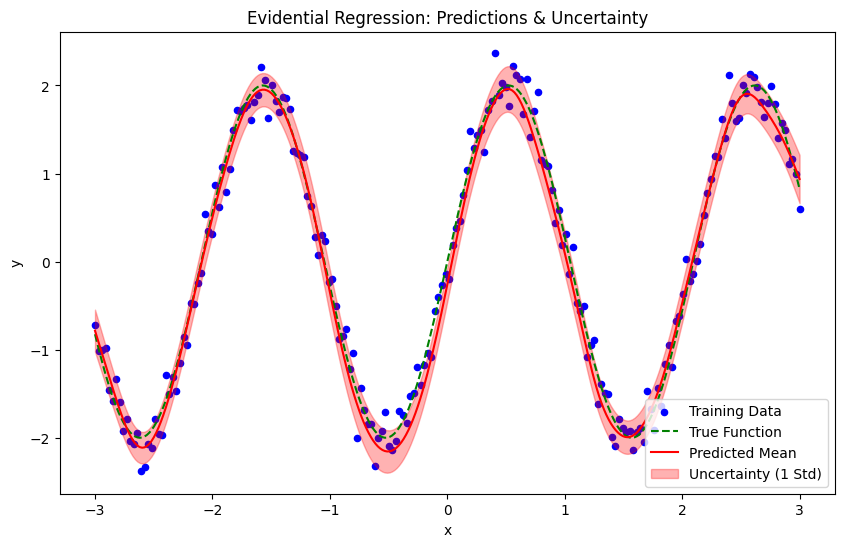

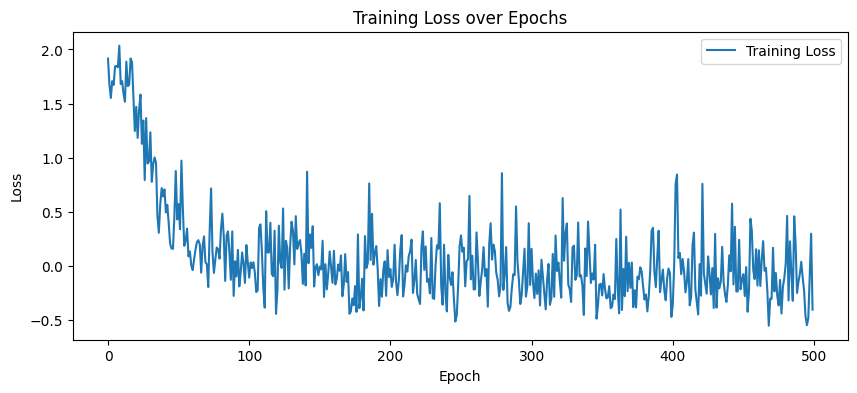

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

# -------------------------------
# Define the Evidential Regression Model
# -------------------------------
class EvidentialRegression(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(EvidentialRegression, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Mish(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
        )
        # The final layer outputs 4 values:
        # [mu, log(v), log(alpha), log(beta)]
        self.out = nn.Linear(hidden_dim, 4)
        self.softplus = nn.Softplus()  # ensures positivity for v, alpha, beta

    def forward(self, x):
        x = self.net(x)
        output = self.out(x)
        # μ (mu) can be any real number
        mu = output[:, 0:1]
        # For the other parameters, we apply softplus to ensure they are positive.
        v = self.softplus(output[:, 1:2])
        # Shift alpha by 1 to ensure α > 1 (a requirement in the NIG formulation)
        alpha = self.softplus(output[:, 2:3]) + 1
        beta = self.softplus(output[:, 3:4])
        return mu, v, alpha, beta

# -------------------------------
# Define the Evidential Loss Function
# -------------------------------
def evidential_loss(y, mu, v, alpha, beta, coeff=1.0):
    """
    Computes the evidential regression loss which is composed of:
      - The negative log marginal likelihood (NLL) of the NIG distribution.
      - A regularization term that penalizes large errors.
    
    The computed loss for each data point is:
    
    L = NLL + coeff * |y - mu|

    Where NLL is given by:
    0.5 * log(pi / v)
      - alpha * log(2*beta*(1+v))
      + (alpha+0.5) * log(v*(y-mu)^2 + 2*beta*(1+v))
      + lgamma(alpha) - lgamma(alpha+0.5)
    """
    two_beta_v = 2 * beta * (1 + v)
    error = y - mu
    nll = 0.5 * torch.log(np.pi / v) \
          - alpha * torch.log(two_beta_v) \
          + (alpha + 0.5) * torch.log(v * error**2 + two_beta_v) \
          + torch.lgamma(alpha) \
          - torch.lgamma(alpha + 0.5)
    loss = nll + coeff * torch.abs(error)
    return torch.mean(loss)

# -------------------------------
# Generate Synthetic Data
# -------------------------------
# For demonstration, we use a noisy sine wave
np.random.seed(42)
torch.manual_seed(42)

N = 200
x = np.linspace(-3, 3, N).reshape(-1, 1)
y_true = 2*np.sin(3*x)  # true function
noise = 0.2 * np.random.randn(N, 1)
y = y_true + noise  # observed data with noise

# Create torch tensors and a DataLoader
x_tensor = torch.from_numpy(x).float()
y_tensor = torch.from_numpy(y).float()
dataset = TensorDataset(x_tensor, y_tensor)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# -------------------------------
# Model Initialization and Training Setup
# -------------------------------
model = EvidentialRegression(input_dim=1, hidden_dim=50)
optimizer = optim.Adam(model.parameters(), lr=0.01)

num_epochs = 500
loss_history = []

# -------------------------------
# Training Loop
# -------------------------------
for epoch in range(num_epochs):
    for batch_x, batch_y in loader:
        optimizer.zero_grad()
        mu, v, alpha, beta = model(batch_x)
        loss = evidential_loss(batch_y, mu, v, alpha, beta, coeff=0.1)
        loss.backward()
        optimizer.step()
    loss_history.append(loss.item())
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")

# -------------------------------
# Evaluation and Visualization
# -------------------------------
model.eval()
with torch.no_grad():
    # Create test inputs for a dense grid
    x_test = torch.linspace(-3, 3, 300).unsqueeze(1)
    mu, v, alpha, beta = model(x_test)
    mu = mu.squeeze().numpy()

    # Convert evidential parameters to numpy arrays
    v_np = v.squeeze().numpy()
    alpha_np = alpha.squeeze().numpy()
    beta_np = beta.squeeze().numpy()

    # Compute the predictive variance.
    # For the Normal-Inverse Gamma, a commonly used expression is:
    # variance = beta * (1 + v) / (v * (alpha - 1)), for α > 1.
    var = beta_np * (1 + v_np) / (v_np * (alpha_np - 1))
    std = np.sqrt(var)  # standard deviation for uncertainty visualization

x_test_np = x_test.squeeze().numpy()

# Plot the training data, true function, predicted mean, and uncertainty bands
plt.figure(figsize=(10, 6))
plt.scatter(x, y, c='blue', label='Training Data', s=20)
plt.plot(x_test_np, 2*np.sin(3*x_test_np), 'g--', label='True Function')
plt.plot(x_test_np, mu, 'r-', label='Predicted Mean')
plt.fill_between(x_test_np, mu - std, mu + std, color='r', alpha=0.3, 
                 label='Uncertainty (1 Std)')
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Evidential Regression: Predictions & Uncertainty")
plt.show()

# Plot training loss over epochs
plt.figure(figsize=(10, 4))
plt.plot(loss_history, label='Training Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss over Epochs")
plt.legend()
plt.show()



Epoch 100/500 | Evidential Loss: 1.0302 | GNLL Loss: 0.9730
Epoch 200/500 | Evidential Loss: 0.8079 | GNLL Loss: 0.8592
Epoch 300/500 | Evidential Loss: 1.1247 | GNLL Loss: 0.9944
Epoch 400/500 | Evidential Loss: 1.1829 | GNLL Loss: 1.1549
Epoch 500/500 | Evidential Loss: 1.0152 | GNLL Loss: 1.0837


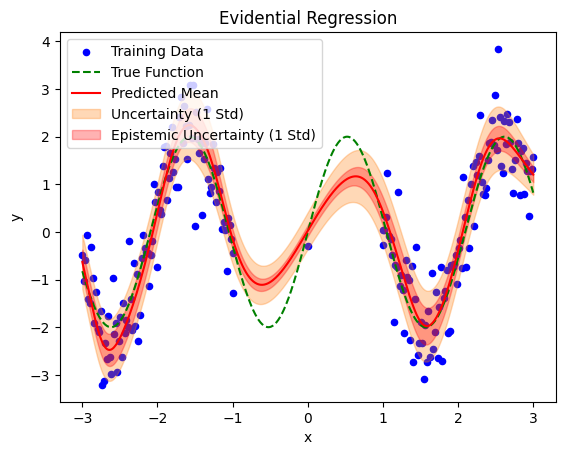

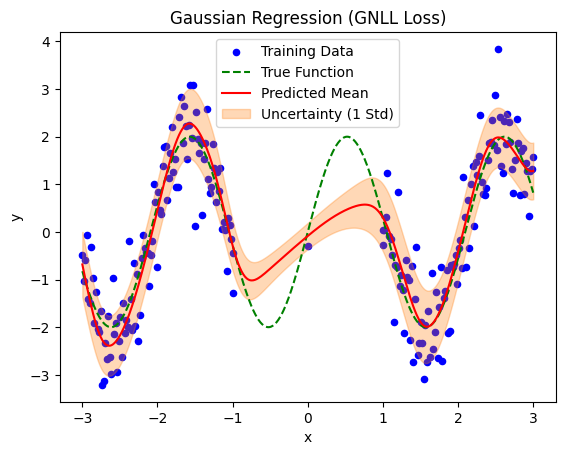

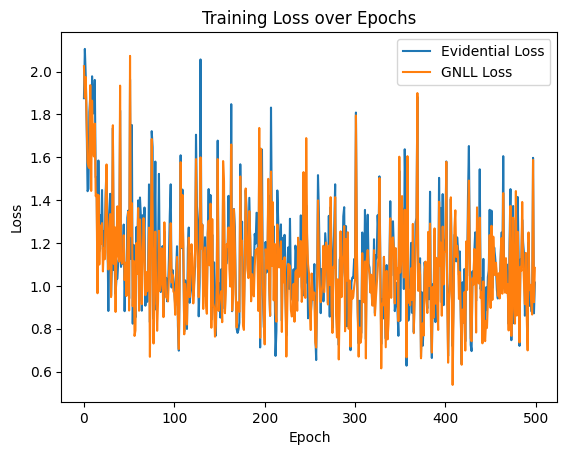

In [65]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

# -------------------------------
# Evidential Regression Model & Loss
# -------------------------------
class EvidentialRegression(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(EvidentialRegression, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Mish(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Mish(),
        )
        # The final layer outputs 4 values: [mu, log(v), log(alpha), log(beta)]
        self.out = nn.Linear(hidden_dim, 4)
        self.softplus = nn.Softplus()  # ensures positivity for v, alpha, beta

    def forward(self, x):
        x = self.net(x)
        output = self.out(x)
        # μ (mu) can be any real number
        mu = output[:, 0:1]
        # For the other parameters, we apply softplus to ensure they are positive.
        v = self.softplus(output[:, 1:2])
        # Shift alpha by 1 to ensure α > 1 (a requirement in the NIG formulation)
        alpha = self.softplus(output[:, 2:3]) + 1
        beta = self.softplus(output[:, 3:4])
        return mu, v, alpha, beta

def evidential_loss(y, mu, v, alpha, beta, coeff=1.0):
    """
    Computes the evidential regression loss, consisting of:
      - The negative log marginal likelihood (NLL) of the NIG distribution.
      - A regularization term: coeff * |y-mu|
    """
    two_beta_v = 2 * beta * (1 + v)
    error = y - mu
    nll = 0.5 * torch.log(np.pi / v) \
          - alpha * torch.log(two_beta_v) \
          + (alpha + 0.5) * torch.log(v * error**2 + two_beta_v) \
          + torch.lgamma(alpha) \
          - torch.lgamma(alpha + 0.5)
    loss = nll + coeff * torch.abs(error)
    return torch.mean(loss)

# -------------------------------
# Gaussian Regression Model & GNLL Loss
# -------------------------------
class GaussianRegression(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(GaussianRegression, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Mish(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Mish(),
        )
        # The final layer outputs 2 values: [mu, sigma_param]
        # We use softplus to ensure sigma is positive.
        self.out = nn.Linear(hidden_dim, 2)
        self.softplus = nn.Softplus()

    def forward(self, x):
        x = self.net(x)
        output = self.out(x)
        mu = output[:, 0:1]
        # Here we obtain a positive standard deviation parameter
        sigma = self.softplus(output[:, 1:2])
        return mu, sigma

def gnll_loss(y, mu, sigma):
    """
    Computes the Gaussian Negative Log Likelihood (GNLL) loss.
    Assumes:
      y ~ N(mu, sigma^2)
    """
    loss = 0.5 * torch.log(2 * np.pi * sigma**2) + 0.5 * ((y - mu)**2 / sigma**2)
    return torch.mean(loss)

# -------------------------------
# Generate Synthetic Data with a Gap in the Middle
# -------------------------------
np.random.seed(42)
torch.manual_seed(42)

N = 203
# Create a gap by sampling points from two separate intervals
N_half = (N-3) // 2
x_left = np.linspace(-3, -1, N_half).reshape(-1, 1)
x_center = np.linspace(-1, 1, 3).reshape(-1, 1)  
x_right = np.linspace(1, 3, N_half).reshape(-1, 1)
x = np.vstack((x_left, x_center ,x_right))

y_true = 2 * np.sin(3 * x)   # true function values
noise = 0.7 * np.random.randn(x.shape[0], 1)
y = y_true + noise         # observed data with noise

# Create torch tensors and a DataLoader
x_tensor = torch.from_numpy(x).float()
y_tensor = torch.from_numpy(y).float()

dataset = TensorDataset(x_tensor, y_tensor)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# -------------------------------
# Model Initialization and Optimizers
# -------------------------------
hidden_dim = 50
# Evidential model and optimizer
evidential_model = EvidentialRegression(input_dim=1, hidden_dim=hidden_dim)
opt_ev = optim.Adam(evidential_model.parameters(), lr=0.01)

# Gaussian model (using GNLL loss) and optimizer
gaussian_model = GaussianRegression(input_dim=1, hidden_dim=hidden_dim)
opt_gnll = optim.Adam(gaussian_model.parameters(), lr=0.01)

num_epochs = 500
loss_history_ev = []
loss_history_gnll = []

# -------------------------------
# Training Loop for Both Models
# -------------------------------
for epoch in range(num_epochs):
    for batch_x, batch_y in loader:
        # --- Evidential Regression Training ---
        opt_ev.zero_grad()
        mu_ev, v_ev, alpha_ev, beta_ev = evidential_model(batch_x)
        loss_ev = evidential_loss(batch_y, mu_ev, v_ev, alpha_ev, beta_ev, coeff=0.1)
        loss_ev.backward()
        opt_ev.step()

        # --- Gaussian Regression Training (GNLL Loss) ---
        opt_gnll.zero_grad()
        mu_gnll, sigma_gnll = gaussian_model(batch_x)
        loss_gnll = gnll_loss(batch_y, mu_gnll, sigma_gnll)
        loss_gnll.backward()
        opt_gnll.step()

    loss_history_ev.append(loss_ev.item())
    loss_history_gnll.append(loss_gnll.item())
    
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} | Evidential Loss: {loss_ev.item():.4f} | GNLL Loss: {loss_gnll.item():.4f}")

# -------------------------------
# Evaluation and Visualization
# -------------------------------
# Create a dense grid for test inputs over the full range [-3, 3]
x_test = torch.linspace(-3, 3, 500).unsqueeze(1)

# Evidential Model Predictions
evidential_model.eval()
with torch.no_grad():
    mu_ev, v_ev, alpha_ev, beta_ev = evidential_model(x_test)
    mu_ev = mu_ev.squeeze().numpy()
    v_ev = v_ev.squeeze().numpy()
    alpha_ev = alpha_ev.squeeze().numpy()
    beta_ev = beta_ev.squeeze().numpy()
    # Compute predictive variance for evidential regression (for α > 1)
    # var_ev = beta_ev * (1 + v_ev) / (v_ev * (alpha_ev - 1))
    var_aleatoric = beta_ev / (alpha_ev - 1)  # aleatoric variance
    var_epistemic = beta_ev / (v_ev * (alpha_ev - 1))  # epistemic variance
    var_ev = var_aleatoric + var_epistemic
    std_aleatoric = np.sqrt(var_aleatoric)
    std_epistemic = np.sqrt(var_epistemic)
    std_ev = np.sqrt(var_ev)

# Gaussian Model Predictions
gaussian_model.eval()
with torch.no_grad():
    mu_gnll, sigma_gnll = gaussian_model(x_test)
    mu_gnll = mu_gnll.squeeze().numpy()
    sigma_gnll = sigma_gnll.squeeze().numpy()  # This is the predicted std

x_test_np = x_test.squeeze().numpy()

# Plot the predictions and uncertainties for both models
plt.figure()

# Evidential Regression Plot
# plt.subplot(2, 1, 1)
plt.scatter(x, y, c='blue', label='Training Data', s=20)
plt.plot(x_test_np, 2*np.sin(3*x_test_np), 'g--', label='True Function')
plt.plot(x_test_np, mu_ev, 'r-', label='Predicted Mean')
plt.fill_between(x_test_np, mu_ev - std_ev, mu_ev + std_ev, color='C1', alpha=0.3, label='Uncertainty (1 Std)')
# plt.fill_between(x_test_np, mu_ev - std_aleatoric, mu_ev + std_aleatoric, color='C2', alpha=0.3, label='Aleatoric Uncertainty (1 Std)')
plt.fill_between(x_test_np, mu_ev - std_epistemic, mu_ev + std_epistemic, color='r', alpha=0.3, label='Epistemic Uncertainty (1 Std)')
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Evidential Regression")
plt.show()

# Gaussian Regression Plot (GNLL Loss)
# plt.subplot(2, 1, 2)
plt.scatter(x, y, c='blue', label='Training Data', s=20)
plt.plot(x_test_np, 2*np.sin(3*x_test_np), 'g--', label='True Function')
plt.plot(x_test_np, mu_gnll, 'r-', label='Predicted Mean')
plt.fill_between(x_test_np, mu_gnll - sigma_gnll, mu_gnll + sigma_gnll, color='C1', alpha=0.3, label='Uncertainty (1 Std)')
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Gaussian Regression (GNLL Loss)")

# plt.tight_layout()
plt.show()

# Plot training loss over epochs for comparison
plt.figure()
plt.plot(loss_history_ev, label='Evidential Loss')
plt.plot(loss_history_gnll, label='GNLL Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss over Epochs")
plt.legend()
plt.show()


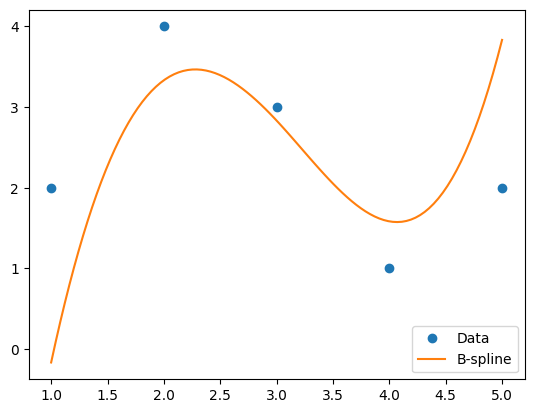

In [58]:
import numpy as np
from scipy.interpolate import BSpline

# Define x and y data
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 3, 1, 2])

# Define degree of B-spline
k = 3

# Define knot vector
t = np.array([1, 1, 1, 2, 3, 4, 5, 5, 5])

# Create B-spline object
spline = BSpline(t, y, k)

# Define x values to interpolate at
x_interp = np.linspace(x.min(), x.max(), 100)

# Interpolate y values
y_interp = spline(x_interp)

# Plot original data and interpolated data
import matplotlib.pyplot as plt
plt.plot(x, y, 'o', label='Data')
plt.plot(x_interp, y_interp, label='B-spline')
plt.legend()
plt.show()